In [5]:
import pandas as pd
import numpy as np

dosya_yolu = r"C:\Users\nefsa\Desktop\Ruh Sağlığı ve Yaşam Tarzı Korelasyonu proje-3\brfss_survey_data_2024.csv"
secilen_kolonlar = ['MENTHLTH', 'ALCDAY4', 'SMOKE100', 'EXERANY2', 'EMTSUPRT', 'MARITAL']

print("Veri yükleniyor.")
df = pd.read_csv(dosya_yolu, usecols=secilen_kolonlar)

# VERİ TEMİZLEME 
df['MENTHLTH'] = df['MENTHLTH'].replace(88, 0)
df['MENTHLTH'] = df['MENTHLTH'].replace([77, 99], np.nan)

# Hedef değişkendeki eksik verileri silme 
df = df.dropna(subset=['MENTHLTH'])

# ALCDAY4: 888 anomalisini 0'a çeviriyoruz. 777 ve 999 geçersiz.
df['ALCDAY4'] = df['ALCDAY4'].replace(888, 0)
df['ALCDAY4'] = df['ALCDAY4'].replace([777, 999], np.nan)

df['SMOKE100'] = df['SMOKE100'].replace([7, 9], np.nan)
df['EXERANY2'] = df['EXERANY2'].replace([7, 9], np.nan)
df['EMTSUPRT'] = df['EMTSUPRT'].replace([7, 9], np.nan)
df['MARITAL'] = df['MARITAL'].replace(9, np.nan)

print("Temizlik tamamlandı. Toplam gözlem sayısı:", len(df))

Veri yükleniyor.
Temizlik tamamlandı. Toplam gözlem sayısı: 449514


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer

print("Veri Eğitim (%80) ve Test (%20) setlerine ayrılıyor.")
# X: Bağımsız Değişkenler (Öznitelikler)
X = df[['EXERANY2', 'SMOKE100', 'ALCDAY4', 'EMTSUPRT', 'MARITAL']]  
# y: Bağımlı Değişken (Hedef: Kötü ruh sağlığı gün sayısı)
y = df['MENTHLTH'] 

# Veriyi Bölme 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("KNN İmputasyonu uygulanıyor veri sızıntısını (Data Leakage) önlemek için KNN İmputasyonu sadece eğitim setinden öğreniliyor.")
# KNN Imputer nesnesini oluşturuyoruz. n_neighbors=5 standart bir başlangıçtır.
# Yani eksik bir veriyi doldurmak için en çok benzeyen 5 kişiye bakacak.
imputer = KNNImputer(n_neighbors=5)

# Eğitim setinden öğren ve doldur
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)

# Test setini doldur (Öğrenme yok, eğitim setinden öğrendikleriyle)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

print("İmputasyon tamamlandı. X_train_imputed ve X_test_imputed hazır.")
print("Eğitim Seti (X_train) Eksik Veri Dağılımı:")
print(X_train_imputed.isnull().sum())
print("\nTest Seti (X_test) Eksik Veri Dağılımı:")
print(X_test_imputed.isnull().sum())

Veri Eğitim (%80) ve Test (%20) setlerine ayrılıyor.
KNN İmputasyonu uygulanıyor veri sızıntısını (Data Leakage) önlemek için KNN İmputasyonu sadece eğitim setinden öğreniliyor.
İmputasyon tamamlandı. X_train_imputed ve X_test_imputed hazır.
Eğitim Seti (X_train) Eksik Veri Dağılımı:
EXERANY2    0
SMOKE100    0
ALCDAY4     0
EMTSUPRT    0
MARITAL     0
dtype: int64

Test Seti (X_test) Eksik Veri Dağılımı:
EXERANY2    0
SMOKE100    0
ALCDAY4     0
EMTSUPRT    0
MARITAL     0
dtype: int64


Keşifsel Veri Analizi (EDA) Sadece Eğitim Seti Üzerinde Yapılıyor.

Eğitim Seti - Değişkenlerin Ruh Sağlığı ile Korelasyonu:
EXERANY2    0.110619
SMOKE100   -0.089245
ALCDAY4    -0.003818
EMTSUPRT    0.177985
MARITAL     0.136591
MENTHLTH    1.000000
Name: MENTHLTH, dtype: float64


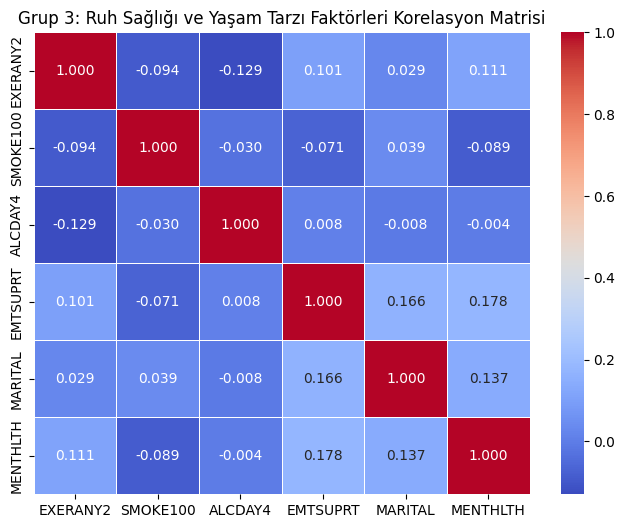

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Keşifsel Veri Analizi (EDA) Sadece Eğitim Seti Üzerinde Yapılıyor.\n")

# Korelasyon için eğitim setindeki bağımlı ve bağımsız değişkenleri geçici olarak birleştiriyoruz
df_train_eda = X_train_imputed.copy()
# İndeksleri sıfırlayarak eşleşmeyi garanti altına alıyoruz
df_train_eda['MENTHLTH'] = y_train.reset_index(drop=True)

korelasyon_matrisi = df_train_eda.corr()
print("Eğitim Seti - Değişkenlerin Ruh Sağlığı ile Korelasyonu:")
print(korelasyon_matrisi['MENTHLTH'])

plt.figure(figsize=(8, 6))
sns.heatmap(korelasyon_matrisi, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5)
plt.title('Grup 3: Ruh Sağlığı ve Yaşam Tarzı Faktörleri Korelasyon Matrisi')
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler

print("Öznitelik Ölçeklendirme (Feature Scaling) uygulanıyor.")
scaler = StandardScaler()

# Scaler eğitim setinden öğrenir ve uygular
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train.columns)

# Test setine sadece uygulanır
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_test.columns)

print("Ölçeklendirme tamamlandı. Veri modellenmeye hazır.")

Öznitelik Ölçeklendirme (Feature Scaling) uygulanıyor.
Ölçeklendirme tamamlandı. Veri modellenmeye hazır.


In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

print("Hiperparametre Optimizasyonu (Grid Search) ile Ridge Regresyon Eğitiliyor.\n")

# Ridge Modeli ve Denenecek Parametreler
ridge_model = Ridge()
param_grid = {'alpha': [0.01, 0.1, 1, 10, 100]}

# 5 Katlı Çapraz Doğrulama (Cross-Validation) ile Grid Search
grid_search = GridSearchCV(ridge_model, param_grid, cv=5, scoring='neg_mean_squared_error')

# Modeli Ölçeklendirilmiş Eğitim Verisi ile Eğit
grid_search.fit(X_train_scaled, y_train)

print(f"En İyi Alpha Parametresi: {grid_search.best_params_['alpha']}")

# En iyi model ile test seti üzerinde tahmin yapma
en_iyi_model = grid_search.best_estimator_
tahminler = en_iyi_model.predict(X_test_scaled)

# Performans Metrikleri
mse = mean_squared_error(y_test, tahminler)
r2 = r2_score(y_test, tahminler)

print("\n MODEL ÇIKTILARI VE PERFORMANS ")
print(f"Model Sabiti (Intercept - Theta 0): {en_iyi_model.intercept_:.4f}")
print("Model Katsayıları:")
for col, coef in zip(X_train.columns, en_iyi_model.coef_):
    print(f"- {col}: {coef:.4f}")

print(f"\nTest Seti MSE (Ortalama Kare Hata): {mse:.4f}")
print(f"Test Seti R-Kare Skoru: {r2:.4f}")

Hiperparametre Optimizasyonu (Grid Search) ile Ridge Regresyon Eğitiliyor.

En İyi Alpha Parametresi: 100

 MODEL ÇIKTILARI VE PERFORMANS 
Model Sabiti (Intercept - Theta 0): 4.4218
Model Katsayıları:
- EXERANY2: 0.7211
- SMOKE100: -0.6289
- ALCDAY4: 0.0401
- EMTSUPRT: 1.2143
- MARITAL: 0.9453

Test Seti MSE (Ortalama Kare Hata): 65.5498
Test Seti R-Kare Skoru: 0.0566


In [11]:
!jupyter nbconvert --to script *.ipynb

[NbConvertApp] Converting notebook brfss2024-mentalhealt.ipynb to script
[NbConvertApp] Writing 5490 bytes to brfss2024-mentalhealt.py
[NbConvertApp] Converting notebook kagglehubdeneme.ipynb to script
[NbConvertApp] Writing 272 bytes to kagglehubdeneme.py
[NbConvertApp] Converting notebook Ucus_Grafigi_Odev.ipynb to script
[NbConvertApp] Writing 736 bytes to Ucus_Grafigi_Odev.py
[NbConvertApp] Converting notebook Untitled.ipynb to script
[NbConvertApp] Writing 38 bytes to Untitled.py
[NbConvertApp] Converting notebook Untitled1.ipynb to script
[NbConvertApp] Writing 70 bytes to Untitled1.py
[NbConvertApp] Converting notebook Untitled10.ipynb to script
[NbConvertApp] Writing 1696 bytes to Untitled10.py
[NbConvertApp] Converting notebook Untitled11.ipynb to script
[NbConvertApp] Writing 336 bytes to Untitled11.py
[NbConvertApp] Converting notebook Untitled12.ipynb to script
[NbConvertApp] Writing 378 bytes to Untitled12.py
[NbConvertApp] Converting notebook Untitled13.ipynb to script
[N